In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
churn=pd.read_csv('churn.csv')

In [ ]:
# ==============================
# 📊 Customer Churn Project Questions (26 Data Analysis)
# ==============================

# 1. What is the overall churn rate of the company? 

# 2. How many customers are active vs churned? 

# 3. What is the age distribution of customers? 

# 4. Which gender has higher churn rate? 

# 5. What is the average tenure of customers?

# 6. Which subscription type is most popular? 

# 7. Which contract length has highest retention? 

# 8. Relationship between tenure and churn? 

# 9. Do high usage frequency customers churn less? 

# 10. Average total spend of churned vs non-churned customers?

# 11. How many support calls made by churned customers?

# 12. Does payment delay affect churn?

# 13. Which age group has highest churn?

# 14. Does long contract reduce churn?

# 15. Which subscription type has highest churn?

# 16. Correlation between support calls and churn?

# 17. Do high spend customers churn less?

# 18. Last interaction vs churn pattern analysis?

# 19. Payment delay distribution among churned customers?

# 20. Which customers are most inactive before churn?

# 21. Identify loyal customers based on tenure and usage?

# 22. Low usage but high spend customer analysis?

# 23. Most important factor affecting churn?

# 24. Customer segmentation based on usage frequency?

# 25. Identify risky customers using rule-based analysis?

# 26. Build customer retention insights report?


# ==============================
# 🤖 Supervised Machine Learning (4 Questions)
# ==============================



#  Logistic Regression: Predict customer churn (Yes/No)

# 29. Decision Tree Classification: Classify churn vs non-churn

# 30. Random Forest Classification: Improve churn prediction accuracy

In [3]:
churn

,CustomerID,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
440827,449995,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440828,449996,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440829,449997,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440830,449998,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


#  What is the overall churn rate of the company? )




In [56]:
count_churn=churn['Churn'].count()

churn_customer=churn[churn['Churn']==1]
churn_count=churn_customer['Churn'].count()

churn_rate=(churn_count/count_churn)*100
print('Total Churn Rate :',churn_rate)


Total Churn Rate : 56.710719729965156


#  How many customers are active vs churned? 


In [3]:
churn['Churn'].value_counts().reset_index()

,Churn,count
0,1,249999
1,0,190833


In [4]:
# 3. What is the age distribution of customers? (age distribution কেমন?)



#  Which gender has higher churn ? 


   Gender   Churn
0  Female  127058
1    Male  122941


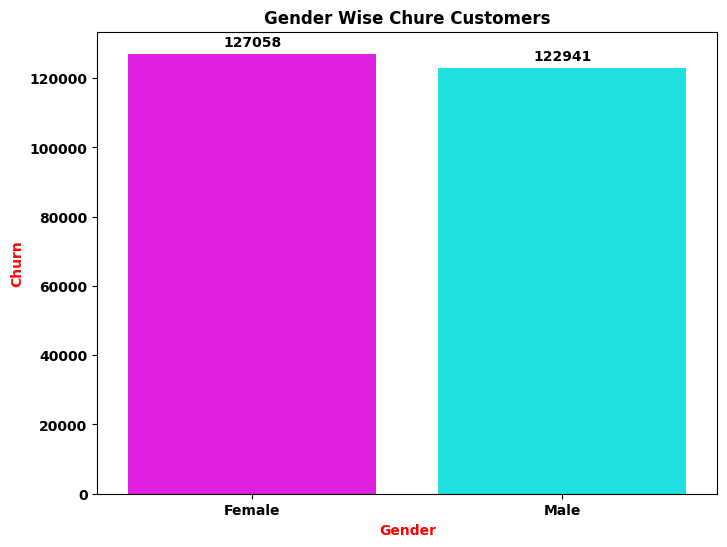

In [3]:
churn_count=churn[churn['Churn']==1]

churn_gender=churn_count.groupby('Gender')['Churn'].count().sort_values(ascending=False).reset_index()
print(churn_gender)
plt.figure(figsize=(8,6))
ax=sns.barplot(data=churn_gender,x='Gender',y='Churn',palette='cool',hue='Churn',legend=False)
plt.title('Gender Wise Chure Customers',color='black',fontweight='bold')
plt.xlabel('Gender',color='red',fontweight='bold')
plt.ylabel('Churn',color='red',fontweight='bold')
plt.xticks(color='black',fontweight='bold')
plt.yticks(color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold')
    


# What is the average tenure of customers? 

In [7]:
average=churn['Tenure'].mean().round(2)
print('Average customer Tenure :',average)

Average customer Tenure : 31.26


#  Which subscription type is most popular? )




In [14]:
churn.groupby('Subscription_Type')['Total_Spend'].sum().sort_values(ascending=False).reset_index().head(1)


,Subscription_Type,Total_Spend
0,Standard,94417746.64


#  Which contract length has highest retention? (



In [5]:
pd.options.display.float_format = '{:.2f}'.format

churn.groupby('Contract_Length').agg({
    'CustomerID':'count',
    'Total_Spend':'sum'
}).sort_values(by='CustomerID',ascending=False).reset_index()
    
    

,Contract_Length,CustomerID,Total_Spend
0,Annual,177198,115479285.38
1,Quarterly,176530,114996322.85
2,Monthly,87104,47961034.49


In [ ]:
# Do high usage frequency customers churn less? 

#  Relationship between tenure and churn?



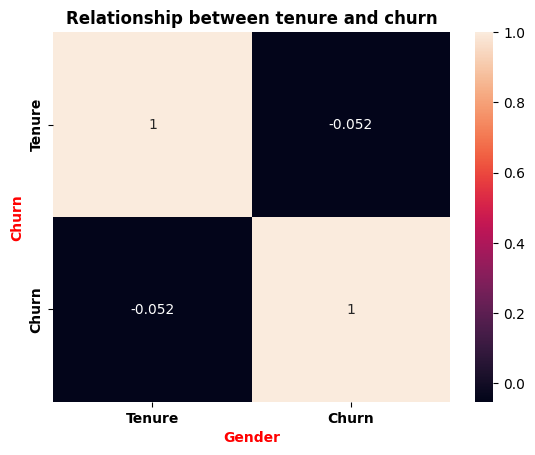

In [45]:
correlation=churn[['Tenure','Churn']].corr()
sns.heatmap(data=correlation,annot=True)
plt.title('Relationship between tenure and churn',color='black',fontweight='bold')
plt.xlabel('Gender',color='red',fontweight='bold')
plt.ylabel('Churn',color='red',fontweight='bold')
plt.xticks(color='black',fontweight='bold')
plt.yticks(color='black',fontweight='bold')
plt.show()

#  Average total spend of churned vs non-churned customers?

In [7]:

pd.options.display.float_format='{:.2f}'.format



,Churn,Total_Spend
0,0,143115802.12
1,1,135320840.60


#  How many support calls made by churned customers?

In [12]:
churn_customers=churn[churn['Churn']==1]
support=churn_customers['Support_Calls'].sum()
print('Support calls :',support)

Support calls : 1286210


#  Does payment delay affect churn?

In [17]:
avg_delay = churn.groupby('Churn')['Payment_Delay'].mean().sort_values(ascending=False).reset_index()
avg_delay

,Churn,Payment_Delay
0,1,15.22
1,0,10.02


# Which age group has highest churn?

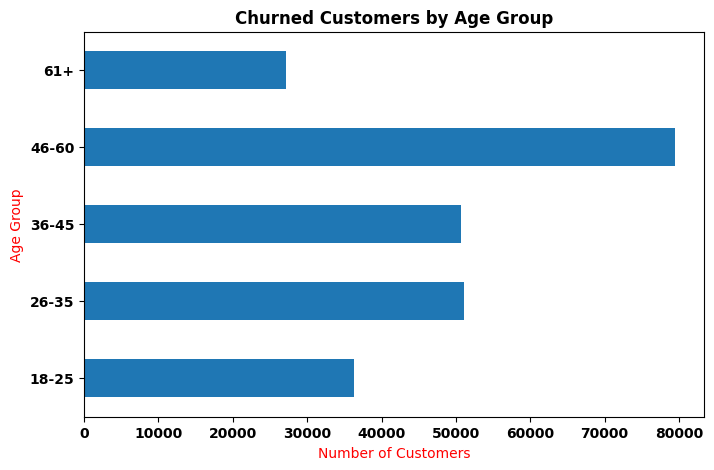

In [61]:
age_group=churn[churn['Churn']==1]
group=age_group.groupby(
    pd.cut(age_group['Age'],
           bins=[18,25,35,45,60,100],
           labels=['18-25','26-35','36-45','46-60','61+']
          )).size()
plt.figure(figsize=(8,5))
group.plot(kind='barh')
plt.title('Churned Customers by Age Group',color='black',fontweight='bold')
plt.xlabel('Number of Customers',color='red')
plt.ylabel('Age Group',color='red')
plt.xticks(color='black',fontweight='bold')
plt.yticks(color='black',fontweight='bold')
plt.show()


#  Does long contract reduce churn?



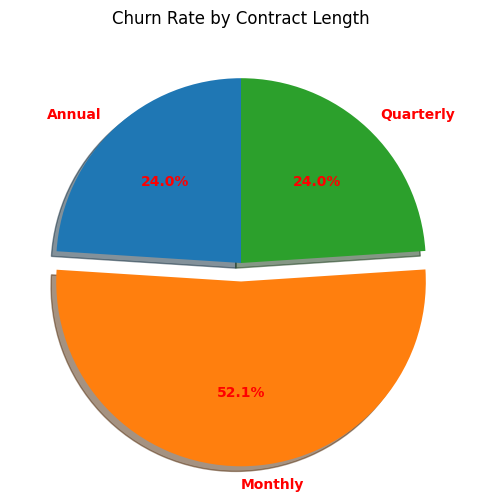

In [63]:
contract_churn = churn.groupby('Contract_Length')['Churn'].mean() * 100

plt.figure(figsize=(6,6))
plt.pie(contract_churn,
        labels=contract_churn.index,
        autopct='%1.1f%%',
        startangle=90,explode=[0,0.1,0],shadow=True,textprops={'weight':'bold','color':'red'})

plt.title('Churn Rate by Contract Length')
plt.show()


#  Which subscription type has highest churn?



In [7]:
count_churn=churn[churn['Churn']==1]
count_churn['Subscription_Type'].value_counts().sort_values(ascending=False).reset_index().head(1)

,Subscription_Type,count
0,Standard,83616


#  Correlation between support calls and churn?



               Support_Calls     Churn
Support_Calls       1.000000  0.574267
Churn               0.574267  1.000000


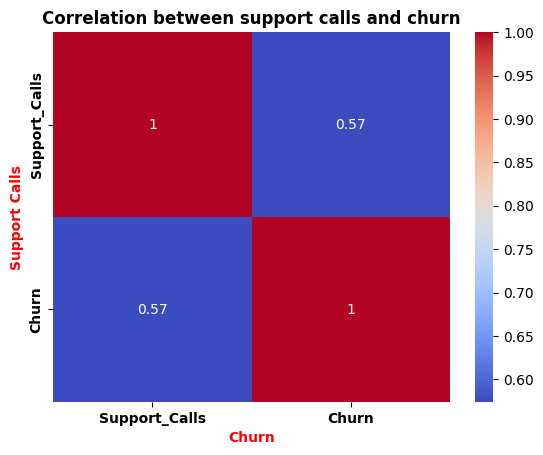

In [26]:

correlations=churn[['Support_Calls','Churn']].corr()
print(correlations)
sns.heatmap(data=correlations,annot=True, cmap="coolwarm")
plt.title('Correlation between support calls and churn',color='black',fontweight='bold')
plt.xlabel('Churn',color='red',fontweight='bold')
plt.ylabel('Support Calls',color='red',fontweight='bold')
plt.xticks(color='black',fontweight='bold')
plt.yticks(color='black',fontweight='bold')
plt.show()

#  Do high spend customers churn less?



In [30]:
churn.groupby('Churn')['Total_Spend'].mean().sort_values(ascending=False).reset_index().round(2)


,Churn,Total_Spend
0,0,749.95
1,1,541.29


#  Last interaction vs churn pattern analysis?




In [36]:
relation=churn['Last_Interaction'].corr(churn['Churn']).round(2)
print('Weak positive correlation between Last Interaction and Churn :',relation)

Weak positive correlation between Last Interaction and Churn : 0.15



#  Payment delay distribution among churned customers?





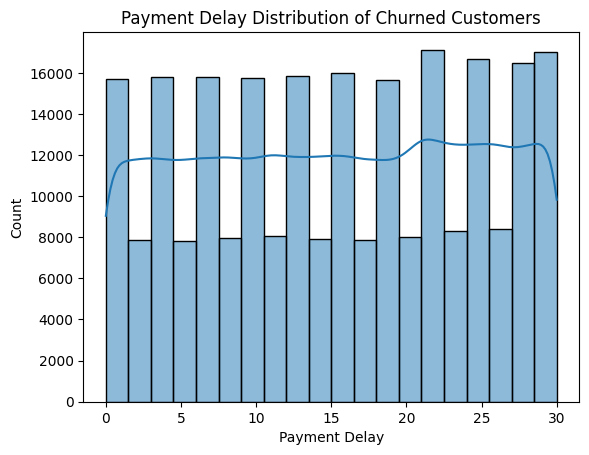

In [41]:
churned = churn[churn['Churn'] == 1]

churned['Payment_Delay'].describe()


sns.histplot(churned['Payment_Delay'], bins=20, kde=True)

plt.title('Payment Delay Distribution of Churned Customers')
plt.xlabel('Payment Delay')
plt.ylabel('Count')

plt.show()


# Which customers are most inactive before churn?

In [49]:
churn_customer=churn[churn['Churn']==1]
inactive_customer=churn_customer.sort_values(by='Last_Interaction',ascending=False)
inactive_customer[['CustomerID','Last_Interaction','Churn']]

,CustomerID,Last_Interaction,Churn
126327,130408,30,1
122325,126240,30,1
17342,17351,30,1
171781,176592,30,1
7745,7754,30,1
...,...,...,...
37019,37257,1,1
4046,4055,1,1
116740,120441,1,1
66913,68431,1,1


#  Identify loyal customers based on tenure and usage?




In [58]:
loyal_customer=(churn[(churn['Tenure']>churn['Tenure'].
    mean()) &(churn['Usage_Frequency']>churn['Usage_Frequency'].mean())])

loyal_customer[
    ['CustomerID', 'Tenure', 'Usage_Frequency']
].head()

,CustomerID,Tenure,Usage_Frequency
3,5,38,21
4,6,32,20
5,8,33,25
12,15,41,17
13,16,35,25


#  Low usage but high spend customer analysis?



In [70]:

customer_analysis=(churn[(churn['Usage_Frequency']<churn['Usage_Frequency'].mean())&
    (churn['Total_Spend']>churn['Total_Spend'].mean())])

customer_analysis[['CustomerID','Usage_Frequency','Total_Spend']].head(10)


,CustomerID,Usage_Frequency,Total_Spend
0,2,14,932.0
6,9,12,821.0
8,11,5,969.0
10,13,9,930.0
11,14,6,830.0
18,21,13,669.0
29,32,15,800.0
35,39,8,939.0
38,43,4,770.0
44,50,7,874.0


#  Most important factor affecting churn?



In [72]:
churn.corr(numeric_only=True)['Churn'].sort_values(ascending=False).reset_index()

,index,Churn
0,Churn,1.000000
1,Support_Calls,0.574267
2,Payment_Delay,0.312129
3,Age,0.218394
4,Last_Interaction,0.149616
5,Usage_Frequency,-0.046101
6,Tenure,-0.051919
7,Total_Spend,-0.429355
8,CustomerID,-0.839365


#  Logistic Regression: Predict customer churn (Yes/No)

In [62]:
churn_copy = churn.copy()

In [63]:
churn_copy.drop(columns=['CustomerID'],inplace=True)

In [64]:
# Categorical columns convert to numerics columns
# Gender,Subscription_Type,Contract_Length

In [65]:
from sklearn.preprocessing import LabelEncoder

In [66]:
la=LabelEncoder()

In [67]:
churn_copy['Gender']=la.fit_transform(churn_copy['Gender'])
churn_copy['Subscription_Type']=la.fit_transform(churn_copy['Subscription_Type'])
churn_copy['Contract_Length']=la.fit_transform(churn_copy['Contract_Length'])

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [69]:
x=churn_copy.drop('Churn',axis=1)
y=churn_copy['Churn']

In [70]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [71]:
model=LogisticRegression()

In [72]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
print('accuracy:',model.score(x_test,y_test)*100)

accuracy: 84.86735399866163


In [17]:
y_pred=model.predict(x_test)

# Accuracy Score

In [18]:
print(accuracy_score(y_test,y_pred))

0.8486735399866163


# confusion matrix

In [19]:
print(confusion_matrix(y_test,y_pred))

[[32181  5882]
 [ 7460 42644]]


# Classification report

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83     38063
           1       0.88      0.85      0.86     50104

    accuracy                           0.85     88167
   macro avg       0.85      0.85      0.85     88167
weighted avg       0.85      0.85      0.85     88167



# Feature importance

In [21]:
importance=pd.DataFrame({
    'Feature':x.columns,
    'importance':model.coef_[0]
})
importance.sort_values(by='importance',ascending=False)

,Feature,importance
4,Support_Calls,0.675511
5,Payment_Delay,0.105141
9,Last_Interaction,0.049223
0,Age,0.032150
3,Usage_Frequency,-0.005286
8,Total_Spend,-0.005635
2,Tenure,-0.007513
7,Contract_Length,-0.089481
6,Subscription_Type,-0.198944
1,Gender,-0.890781


In [22]:
if y_pred[0]==1:
    print('Churn Customer Yes')
else:
    print('Not Churn Customer No')

Churn Customer Yes


In [73]:
y_pred=model.predict([[25,	0,	6,	1,	0,	8,	0,	1,	557.0,6]])
y_pred

array([0])

In [24]:
if y_pred[0]==1:
    print('Churn Customer')
else:
    print('Not Churn Customer')

Not Churn Customer


#  Decision Tree Classification: Classify churn vs non-churn

In [31]:
decision = churn.copy()

In [33]:
decision.head(2)

,CustomerID,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1


In [34]:
decision.drop(columns=['CustomerID'],inplace=True)

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
le=LabelEncoder()

In [37]:
decision['Gender']=le.fit_transform(decision['Gender'])
decision['Subscription_Type']=le.fit_transform(decision['Subscription_Type'])
decision['Contract_Length']=le.fit_transform(decision['Contract_Length'])

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [39]:
x=decision.drop('Churn',axis=1)
y=decision['Churn']

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
model=DecisionTreeClassifier()

In [42]:
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [43]:
print('accuracy:',model.score(x_test,y_test)*100)

accuracy: 99.98071840938219


In [44]:
result=model.predict(x_test)

# result Accuracy

In [46]:
print(accuracy_score(y_test,result)*100)

99.98071840938219


# confusion martrix

In [48]:
print(confusion_matrix(y_test,result))

[[38057     6]
 [   11 50093]]


In [49]:
print(classification_report(y_test,result))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38063
           1       1.00      1.00      1.00     50104

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



# feature importance

In [53]:
importance=pd.DataFrame({
    'feature':x.columns,
    'importance':model.feature_importances_
})
importance.sort_values(by='importance',ascending=False)

,feature,importance
4,Support_Calls,0.359228
8,Total_Spend,0.242403
0,Age,0.144759
5,Payment_Delay,0.130800
7,Contract_Length,0.057836
9,Last_Interaction,0.047642
2,Tenure,0.007560
1,Gender,0.007151
6,Subscription_Type,0.002037
3,Usage_Frequency,0.000584


In [54]:
if result[0]==1:
    print('Churn Customer')
else:
    print('Not Churn Customer')

Churn Customer


# 30. Random Forest Classification: Improve churn prediction accuracy

In [3]:
forest=churn.copy()

# EDA Stape

In [4]:
forest.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage_Frequency      0
Support_Calls        0
Payment_Delay        0
Subscription_Type    0
Contract_Length      0
Total_Spend          0
Last_Interaction     0
Churn                0
dtype: int64

In [5]:
forest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  int64  
 1   Age                440832 non-null  int64  
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  int64  
 4   Usage_Frequency    440832 non-null  int64  
 5   Support_Calls      440832 non-null  int64  
 6   Payment_Delay      440832 non-null  int64  
 7   Subscription_Type  440832 non-null  object 
 8   Contract_Length    440832 non-null  object 
 9   Total_Spend        440832 non-null  float64
 10  Last_Interaction   440832 non-null  int64  
 11  Churn              440832 non-null  int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 40.4+ MB


In [6]:
forest.drop(columns=['CustomerID'],inplace=True)

In [7]:
forest.columns

Index(['Age', 'Gender', 'Tenure', 'Usage_Frequency', 'Support_Calls',
       'Payment_Delay', 'Subscription_Type', 'Contract_Length', 'Total_Spend',
       'Last_Interaction', 'Churn'],
      dtype='object')

In [8]:
numerical_columns=['Age', 'Tenure', 'Usage_Frequency', 'Support_Calls',
       'Payment_Delay','Total_Spend',
       'Last_Interaction', 'Churn']

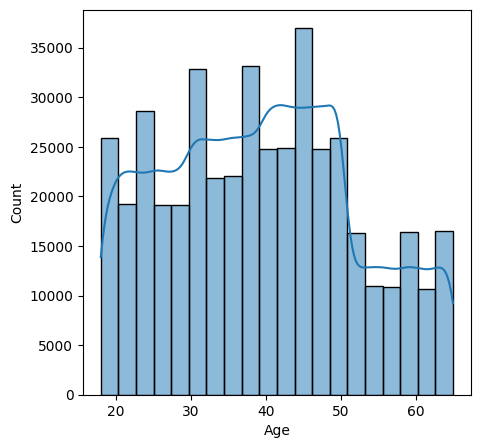

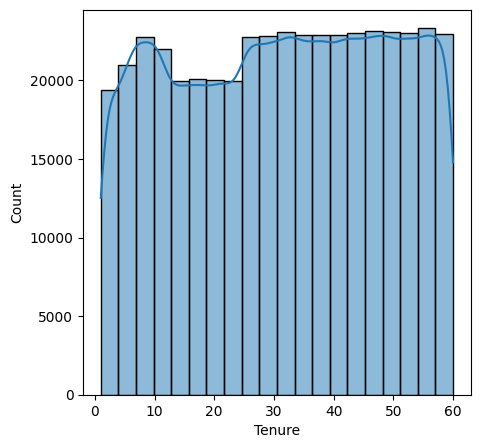

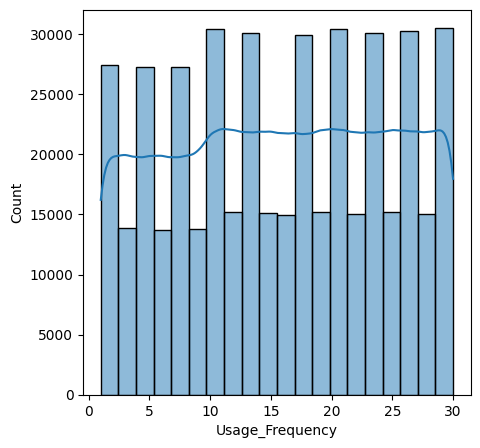

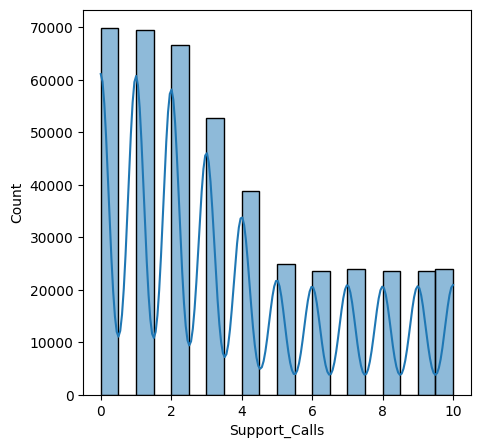

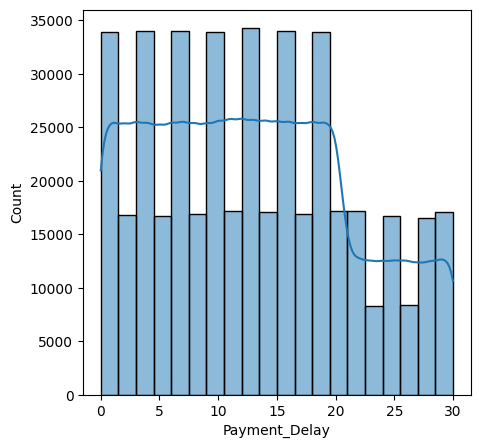

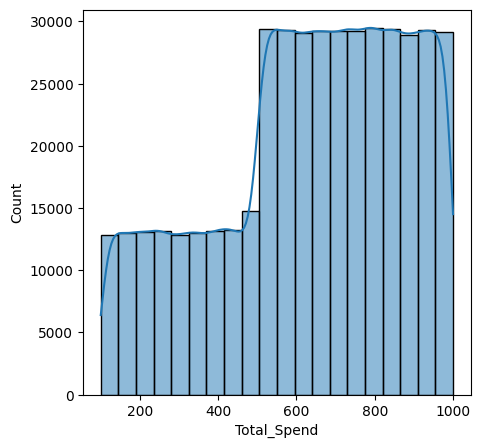

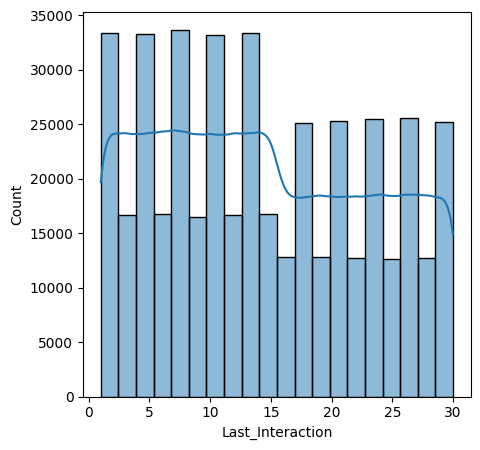

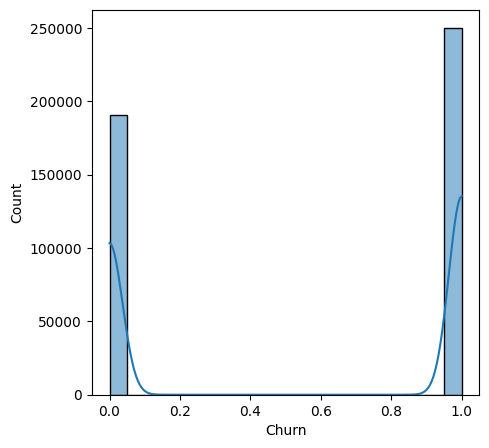

In [9]:
for col in numerical_columns:
    plt.figure(figsize=(5,5))
    sns.histplot(forest[col],kde=True,bins=20)

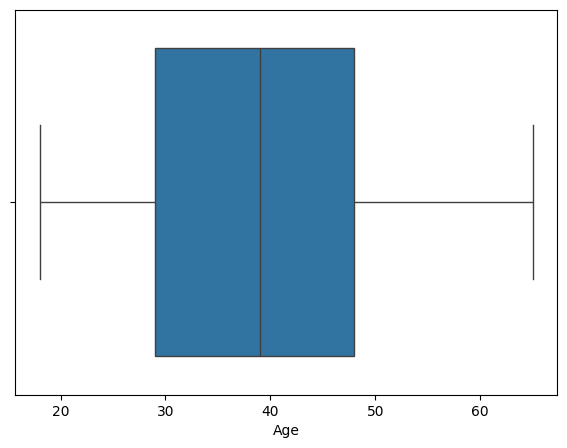

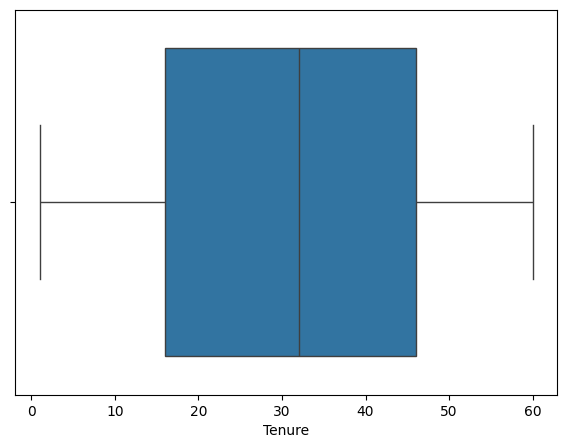

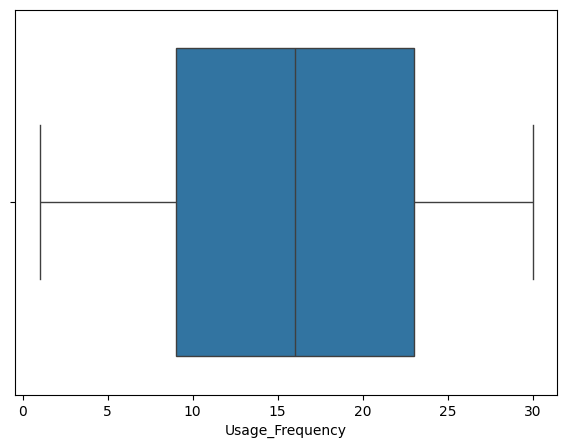

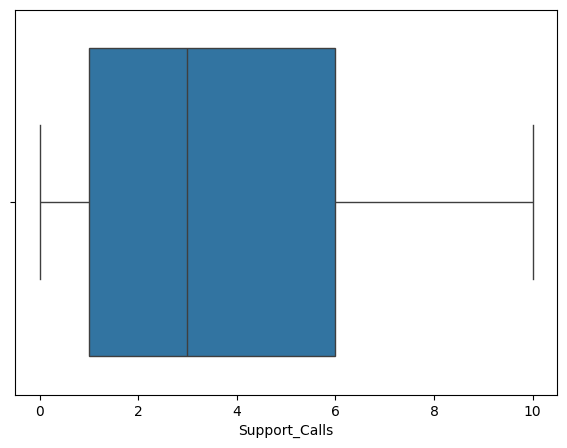

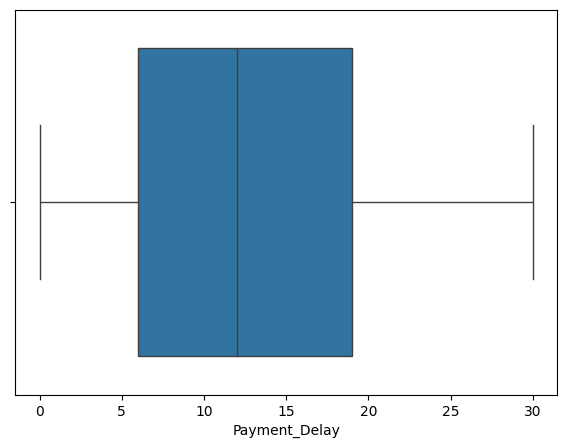

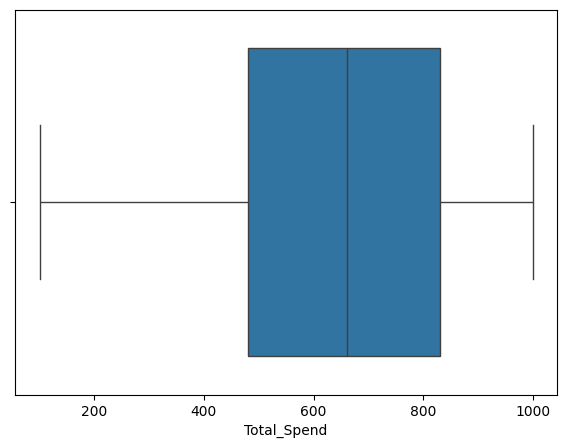

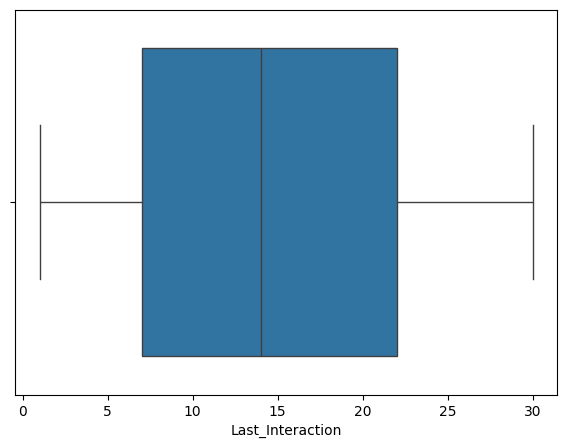

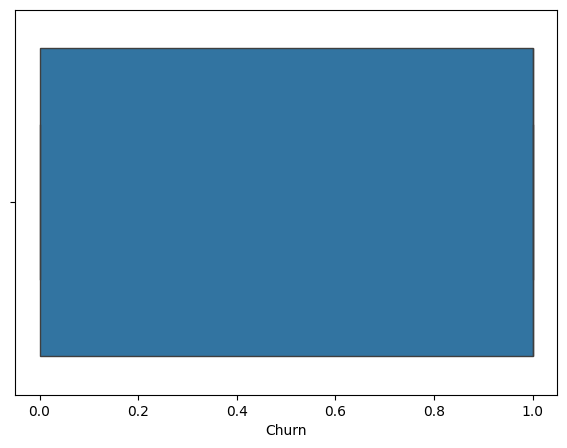

In [10]:
for i in numerical_columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=forest[i])

<Axes: >

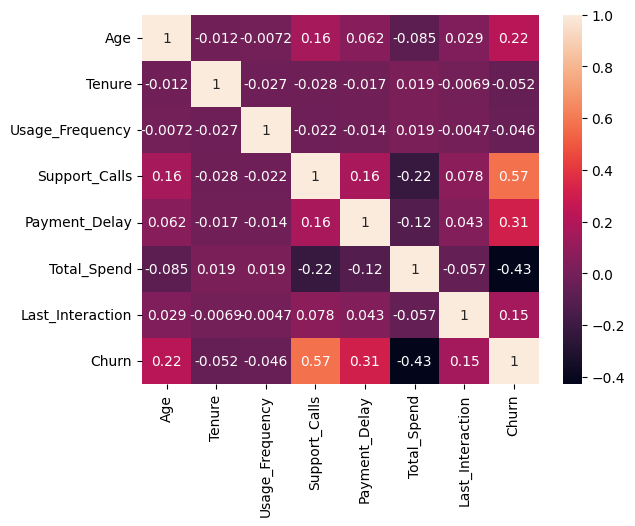

In [11]:
sns.heatmap(forest.corr(numeric_only=True),annot=True)

 # data cleaning

In [12]:
forest.drop_duplicates()

,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...
440827,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440828,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440829,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440830,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


# labelEncoding(Gender)

In [13]:
forest['Gender'].value_counts()

Gender
Male      250252
Female    190580
Name: count, dtype: int64

In [14]:
forest['Gender']=forest['Gender'].map({
    'Male':0,
    'Female':1
})

# OneHotEncoding(Subscription_Type,Contract_Length)

In [15]:
forest=pd.get_dummies(forest,columns=['Subscription_Type'],drop_first=True)
forest=pd.get_dummies(forest,columns=['Contract_Length'],drop_first=True)

In [20]:
forest.astype(int)

,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Total_Spend,Last_Interaction,Churn,Subscription_Type_Premium,Subscription_Type_Standard,Contract_Length_Monthly,Contract_Length_Quarterly
0,30,1,39,14,5,18,932,17,1,0,1,0,0
1,65,1,49,1,10,8,557,6,1,0,0,1,0
2,55,1,14,4,6,18,185,3,1,0,0,0,1
3,58,0,38,21,7,7,396,29,1,0,1,1,0
4,23,0,32,20,5,8,617,20,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440827,42,0,54,15,1,3,716,8,0,1,0,0,0
440828,25,1,8,13,1,20,745,2,0,1,0,0,0
440829,26,0,35,27,1,5,977,9,0,0,1,0,1
440830,28,0,55,14,2,0,602,2,0,0,1,0,1


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [24]:
x=forest.drop('Churn',axis=1)
y=forest['Churn']

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [28]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [30]:
print('accuracy:',model.score(x_test,y_test)*100)

accuracy: 99.16635475858314


In [31]:
y_predict=model.predict(x_test)


# y_predict accuracy

In [33]:
print(accuracy_score(y_test,y_predict)*100)

99.16635475858314


# confusion matrix

In [34]:
print(confusion_matrix(y_test,y_predict))

[[38063     0]
 [  735 49369]]


# classification report

In [35]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     38063
           1       1.00      0.99      0.99     50104

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167



# Feature importance

In [38]:
importance=pd.DataFrame({
    'Feature':x.columns,
    'importance': model.feature_importances_
})
importance.sort_values(by='importance',ascending=False)

,Feature,importance
4,Support_Calls,0.304724
6,Total_Spend,0.219994
10,Contract_Length_Monthly,0.136788
5,Payment_Delay,0.132735
0,Age,0.131032
7,Last_Interaction,0.034476
1,Gender,0.030959
11,Contract_Length_Quarterly,0.004309
2,Tenure,0.003196
3,Usage_Frequency,0.001473


In [39]:
if y_predict[0]==1:
    print('churn')
else:
    print('not churn')

churn
